# Literature Review

**Traffic Management Framework**

**Source**- https://ascelibrary.org/doi/10.1061/JHTRCQ.0000857 

Traffic studies optimize road safety, mitigate congestion, and inform structural transportation planning.

**Outcomes**
* Signal optimization and adaptive timing
* Lane management and speed limit calibration
* Roadway design and future infrastructure expansion

**Primary Traffic Performance Factors**

* **Flow & Demand:** Vehicle volume and peak-hour rush windows.
* **Infrastructure Design:** Lane configurations, barriers, and access management.
* **Control Systems:** Traffic signals, signage, and pedestrian/bicycle crosswalks.
* **Safety Metrics:** Incident history and localized accident-prone conditions.

**Traffic Prediction Research Summary**

**Source** - https://www.sciencedirect.com/science/article/pii/S2212420924009014

This study utilizes statistical and Machine Learning models to predict road network traffic volume based on geographic, socio-economic, and structural features to overcome limited sensor coverage.

**Key Traffic Volume Determinants**

* **Socio-Economic Factors:** High population density, employment hubs, and tourism activity directly increase vehicle volume.
* **Urban Geography:** High urban density and closer proximity to major cities generate higher traffic levels.
* **Road Infrastructure:** Wider roads (more lanes), high accessibility/connectivity, and complex intersections or ring roads attract and concentrate maximum vehicle flow.

# Importing all the essential Libraries¶

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("traffic.csv")
df.sample(6)

,DateTime,Junction,Vehicles,ID
38300,2016-11-14 20:00:00,3,15,20161114203
20305,2016-06-26 01:00:00,2,8,20160626012
16704,2016-01-28 00:00:00,2,14,20160128002
30181,2015-12-12 13:00:00,3,4,20151212133
20290,2016-06-25 10:00:00,2,6,20160625102
34156,2016-05-26 04:00:00,3,4,20160526043


## Dataset Overview

In [3]:
df.shape

(48120, 4)

In [5]:
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [6]:
df.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

#### Purpose of Eda :  WHEN and WHY traffic becomes high or low.

# Hypothesis :
1. Weekday traffic is significantly higher than weekend traffic.
2. Certain junctions carry consistently heavier traffic than others.
3. Traffic patterns vary across months due to seasonal or social factors, Is traffic seasonal?
4. raffic is gradually increasing over years due to urban growth.

### Dataset Checking 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [7]:
df.describe(include="all")

,DateTime,Junction,Vehicles,ID
count,48120,48120.000000,48120.000000,4.812000e+04
unique,14592,NaN,NaN,NaN
top,2017-06-30 08:00:00,NaN,NaN,NaN
freq,4,NaN,NaN,NaN
mean,NaN,2.180549,22.791334,2.016330e+10
std,NaN,0.966955,20.750063,5.944854e+06
min,NaN,1.000000,1.000000,2.015110e+10
25%,NaN,1.000000,9.000000,2.016042e+10
50%,NaN,2.000000,15.000000,2.016093e+10
75%,NaN,3.000000,29.000000,2.017023e+10


In [12]:
df.duplicated().sum()

np.int64(0)

- **1. No miswsing values**
- **2. Vehicle Values- 1- 180 , This looks reasonable, Traffics naturally can have peaks**

### Create Time Features

In [3]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
# Extract features
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Date'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day_name()

df['Week_Type'] = np.where(df['Day'].isin(['Saturday','Sunday']),
                         'Weekend','Weekday')
# Check extracted columns
print(df[['DateTime', 'Year', 'Month','Date', 'Day', 'Hour','Week_Type']].head())

             DateTime  Year  Month  Date     Day  Hour Week_Type
0 2015-11-01 00:00:00  2015     11     1  Sunday     0   Weekend
1 2015-11-01 01:00:00  2015     11     1  Sunday     1   Weekend
2 2015-11-01 02:00:00  2015     11     1  Sunday     2   Weekend
3 2015-11-01 03:00:00  2015     11     1  Sunday     3   Weekend
4 2015-11-01 04:00:00  2015     11     1  Sunday     4   Weekend


In [9]:
df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Date,Hour,Day,Week_Type
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,Sunday,Weekend
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,Sunday,Weekend
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,Sunday,Weekend
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,Sunday,Weekend
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,Sunday,Weekend


In [11]:
df.shape

(48120, 10)

In [10]:
df.nunique()

DateTime     14592
Junction         4
Vehicles       141
ID           48120
Year             3
Month           12
Date            31
Hour            24
Day              7
Week_Type        2
dtype: int64

## **Univariate Analysis :**

### Junction :

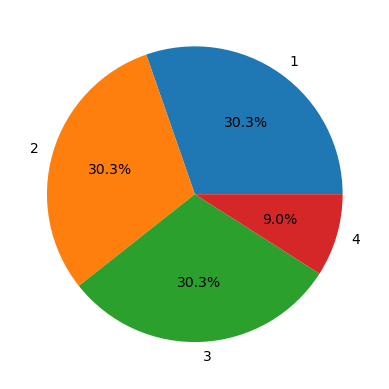

In [12]:
df['Junction'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('') 
plt.show()

he dataset is balanced for Junctions 1, 2, and 3, but Junction 4 has much fewer records. This means Junction 4 may need careful interpretation because its traffic behavior is based on less available data

## Vehicle Distribution :

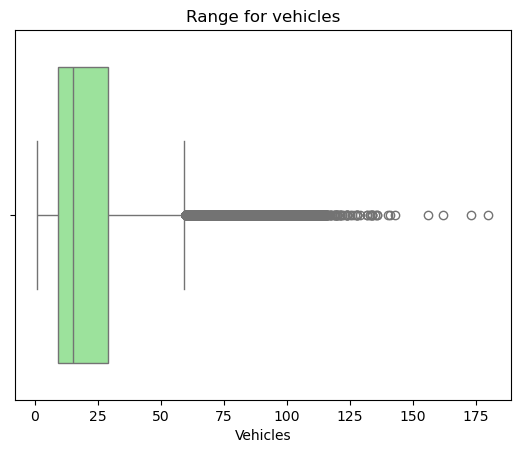

In [46]:
sns.boxplot(x=df['Vehicles'], color='lightgreen')
plt.title('Range for vehicles')
plt.show()

- Most traffic values remain within a moderate range, but the dataset contains several extreme traffic spikes. These outliers likely represent real-world congestion events rather than data errors. This shows that the city occasionally experiences severe traffic pressure at specific times or locations.

## **Bivariate Analysis :**

### Traffic Trend over the years :

<Axes: xlabel='DateTime'>

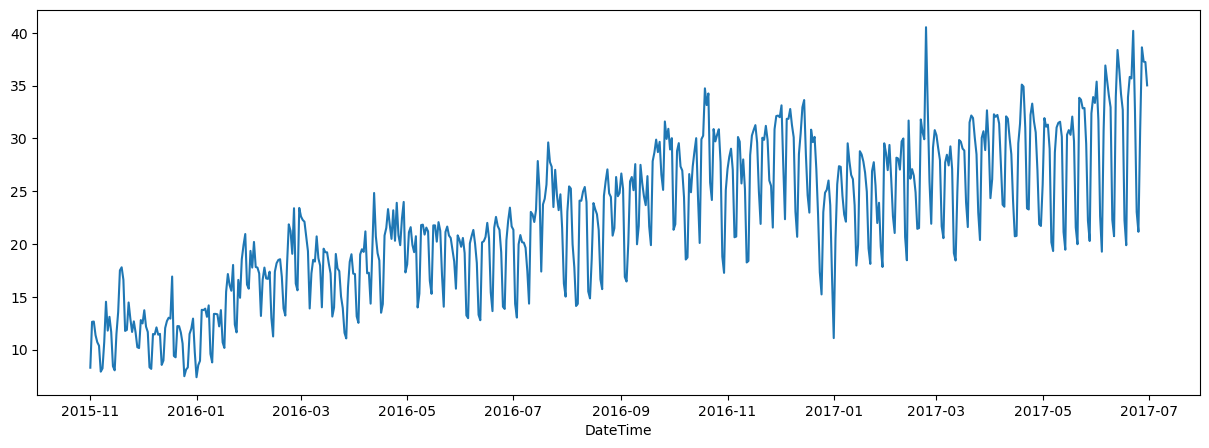

In [55]:
daily = df.groupby(df['DateTime'].dt.date)['Vehicles'].mean()
daily.plot(figsize=(15,5))

- The daily average traffic volume of vehicles across the city over time from late 2015 to mid-2017.
- roads generally becoming more crowded over the years traffic demand is growing month after month.
- 

### Day vs Vehicles :

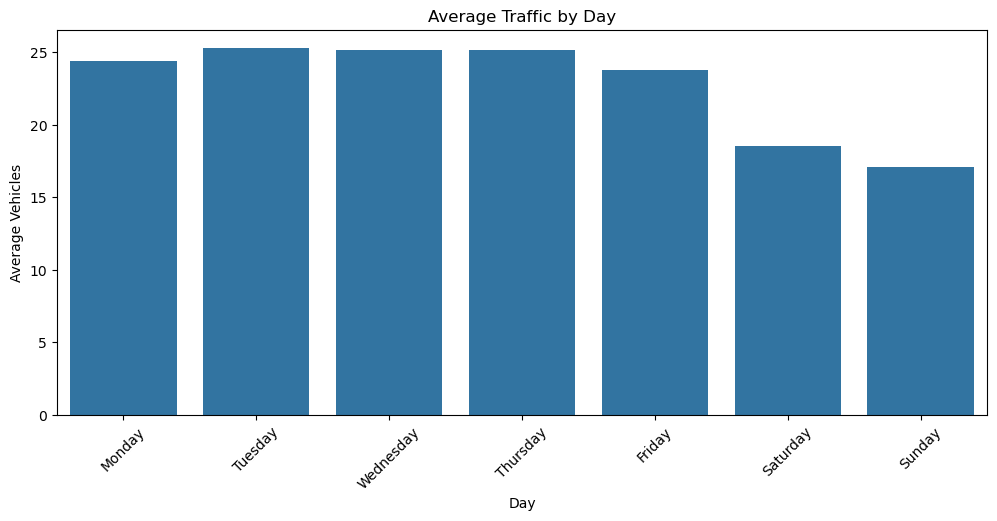

In [33]:
day_traffic = df.groupby('Day')['Vehicles'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.barplot(x='Day',y='Vehicles',data=day_traffic,order=day_order)
plt.title("Average Traffic by Day")
plt.xlabel("Day")
plt.ylabel("Average Vehicles")
plt.xticks(rotation=45)
plt.show()

- Tuesday–Thursday: These are the heaviest traffic days(city’s strongest operational/business/productivity days.)
- Traffic starts slightly decreasing.
- Saturday & Sunday: Traffic drops sharply this shows Traffic is strongly work-driven.
  

### Traffic by Hour

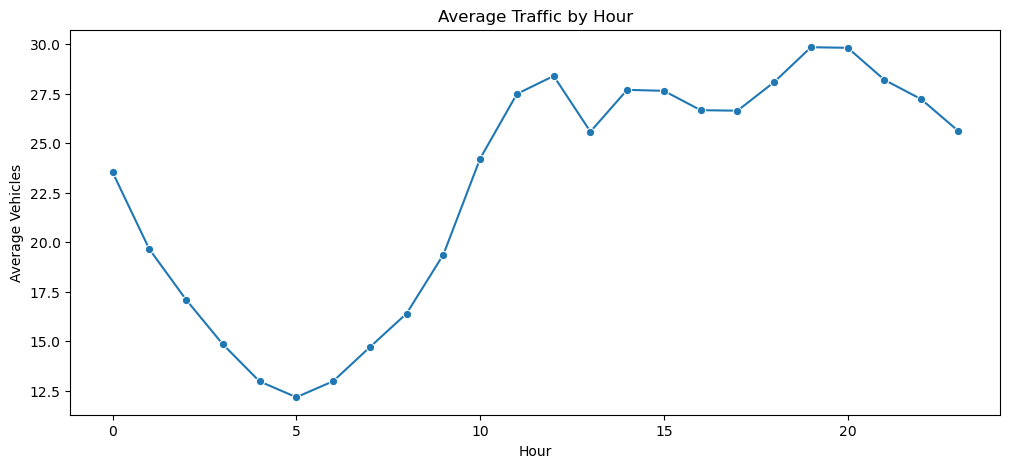

In [5]:
hourly_traffic = df.groupby('Hour')['Vehicles'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(x='Hour', y='Vehicles', data=hourly_traffic,marker='o')
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.show()

- Lowest Traffic at Midnight to Early Morning (12 AM – 5 AM) - most people are sleeping, fewer vehicles on roads
- Traffic starts rising rapidly after - 6–7 AM
- Peak Traffic Around Midday - active logistics movement, supply chain transport, delivery operations,business transportation.
- The city remains economically active through the day, cities no longer operate only on office schedules.
- highest traffic period around 7–8 PM Evening, Traffic Rises Again - people returning home, shopping,evening travel.
- Night Slowdown (After 9 PM)- Traffic gradually declines again.


## Traffic by Month

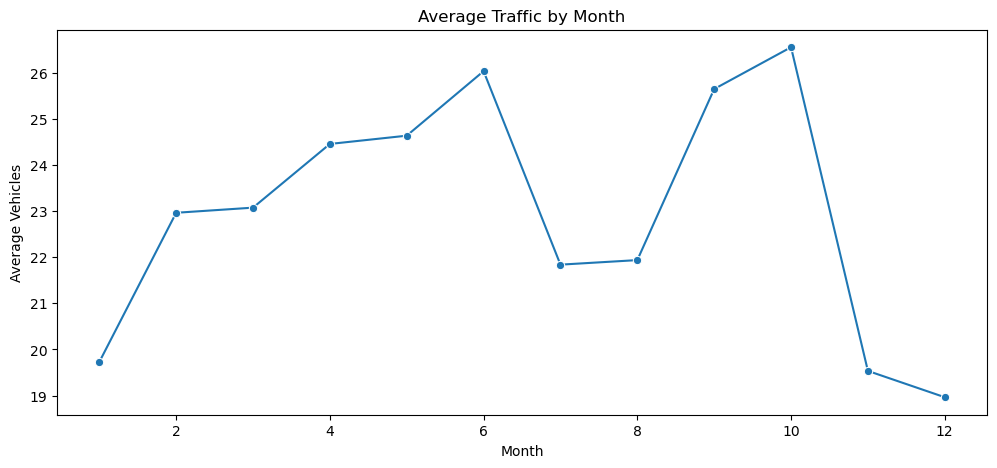

In [6]:
Monthly_traffic = df.groupby('Month')['Vehicles'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(x='Month', y='Vehicles', data=Monthly_traffic,marker='o')
plt.title("Average Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Average Vehicles")
plt.show()

1. Traffic gradually rises from: January → June
2. Traffic decreases in july - august. reason: bad weather condition,monsoon, reduced outdoor movement.
3. October has one of the highest average traffic values.
4. Traffic decreases sharply near:November,December,Possible reasons: holidays/vacation periods, ,year-end vacations,colder weather.
5. Traffic volume changes seasonally and is not constant throughout the year.

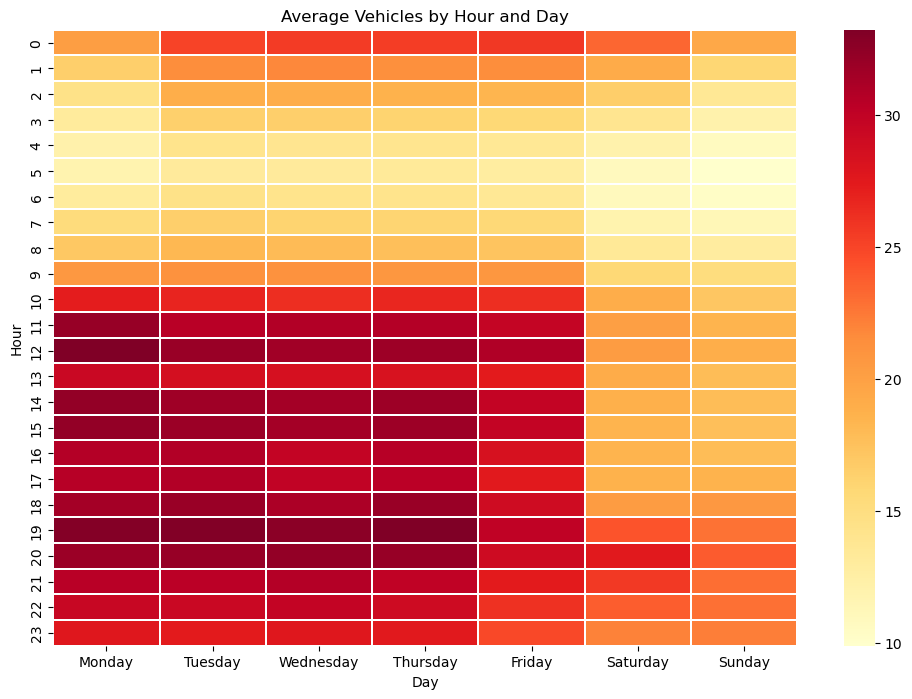

In [48]:
pivot_day_hour = df.pivot_table(values="Vehicles",index="Hour",columns="Day",aggfunc="mean"
).reindex(index=range(0, 24), columns=day_order)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_day_hour, cmap="YlOrRd", linewidths=0.3)
plt.title("Average Vehicles by Hour and Day")
plt.xlabel("Day")
plt.ylabel("Hour")
plt.show()

identifies the exact day-hour where traffic congestion is strongest, which is very useful for route planning and signal timing.


## REAL traffic per junction

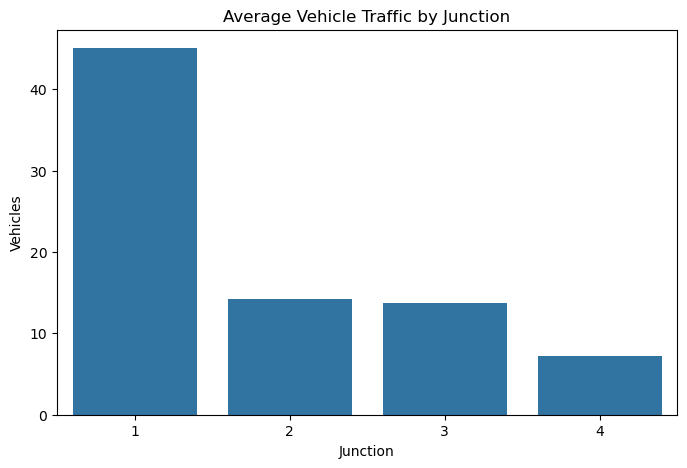

In [7]:
junction_traffic = df.groupby('Junction')['Vehicles'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(x='Junction',
            y='Vehicles',
            data=junction_traffic)

plt.title("Average Vehicle Traffic by Junction")

plt.show()

- junction 1 truly has highest traffic volume, reason for this could be that: busy city roads, commercial areas, office routes, major transportation paths.
- Junctions 2 & 3 = Moderate Activity Zones , reason : mixed-use areas,secondary commercial roads
- junction 4 = less commercially active region, reason: less populated area, residential zone, less important route
- **the city heavily depends on one major transportation node.whenever one junction becomes disproportionately important:congestion risk,infrastructure stress,systemic vulnerability, all increase significantly.**

## Multivariate Analysis :

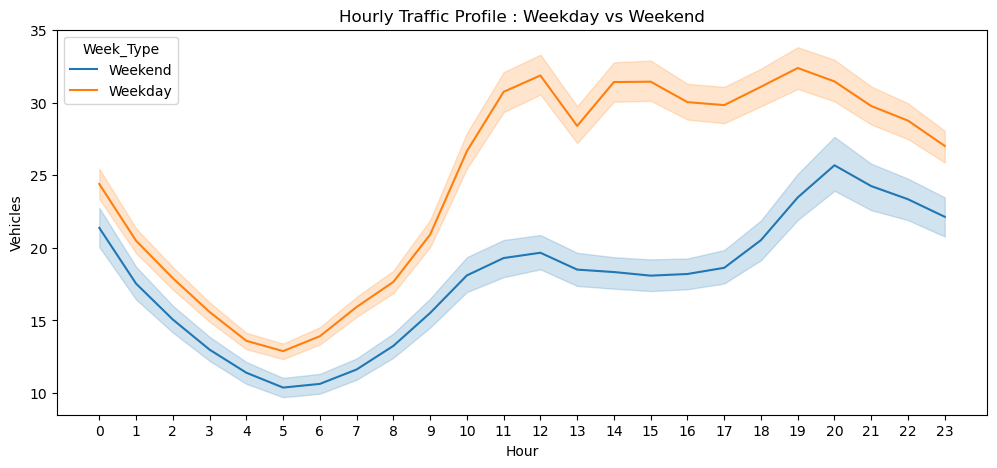

In [42]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Hour',y='Vehicles',hue='Week_Type',data=df)
plt.xticks(range(0,24,1))   # shows every hour
plt.title("Hourly Traffic Profile : Weekday vs Weekend")
plt.show()

1. Lowest Traffic at Early Morning (12 AM – 5 AM)Both weekday and weekend.
2. Weekday traffic rises MUCH faster than weekend, Suddenly Increases After Morning - office timing,school timing, morning commuting
3. Weekdays remain heavily congested Midday & Evening.
4. Weekend Traffic is Always Lower - stays below weekday line almost everywhere, but still rises in evening hours(weekends are:relaxed but still socially active.)
5. work-driven transportation dominates the city, but social and entertainment movement also plays an important role during weekends.


## Junction & Week_Type & Vehicle

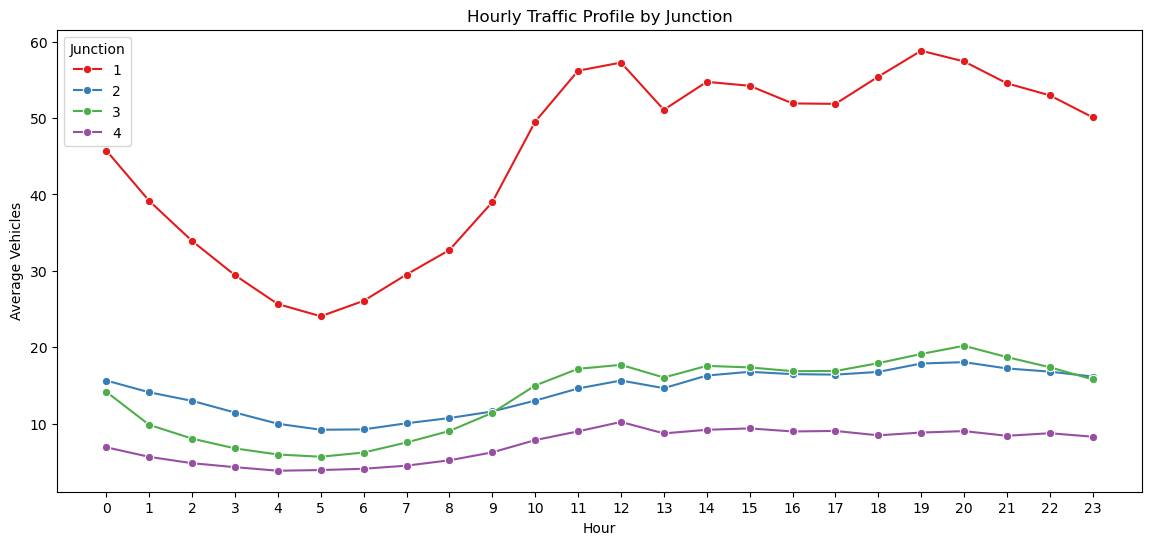

In [46]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="Hour", y="Vehicles", hue="Junction", estimator="mean", errorbar=None, marker="o", palette="Set1")
plt.title("Hourly Traffic Profile by Junction")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.xticks(range(0, 24))
plt.legend(title="Junction")
plt.show()

- junction 1 is dramatically busier than all others at ALL hours.Around 10 AM onward, espicially 6 PM - 9 PM, traffic becomes extremely high.
- Junctions 2 & 3 behave similarly,balanced traffic distribution.
- Junction 4 remains low throughout the day.
- This graph indirectly classifies junctions into:
1. commercial
2. mixed-use
3. residential , without needing external geographic data.

### Junction Vs Day vs Vehicle :

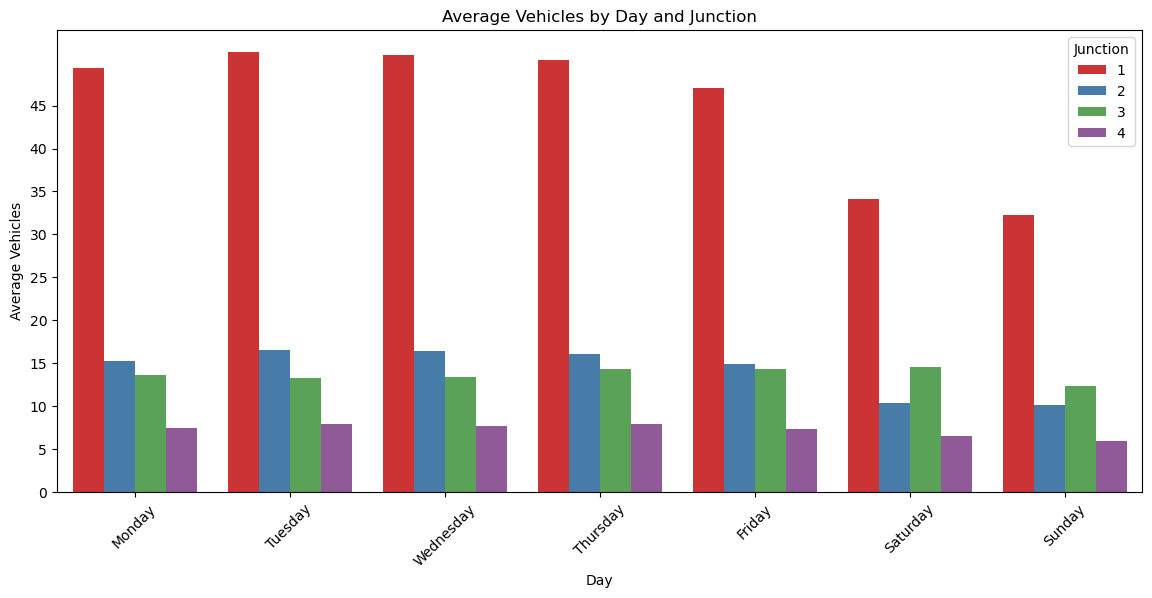

In [63]:
junction_day = (df.groupby(["Junction", "Day"],
            observed=True)["Vehicles"].mean().reset_index())
plt.figure(figsize=(14, 6))
sns.barplot(data=junction_day, x="Day", y="Vehicles", hue="Junction", order=day_order, palette="Set1")
plt.title("Average Vehicles by Day and Junction")
plt.xlabel("Day")
plt.ylabel("Average Vehicles")
plt.xticks(rotation=45)
plt.yticks(range(0, 50,5))
plt.legend(title="Junction")
plt.show()

- Unlike Junction 2,,Junction 3 does not collapse as strongly on weekends.This is a VERY interesting hidden insight.Possible reasons: shopping areas, entertainment zones, residential-social movement.
- Traffic decreases on weekends, especially at Junction 1, which suggests it is mainly connected to office and business activity.
- Junction 4 has the lowest traffic and likely represents a quieter residential area.

### Correlation Matrix

The heatmap shows that traffic is mainly influenced by junction location and daily time patterns rather than by specific dates or months. Junction 1 consistently experiences the heaviest traffic, while traffic also increases slightly over the years, indicating growing urban movement and transportation demand.

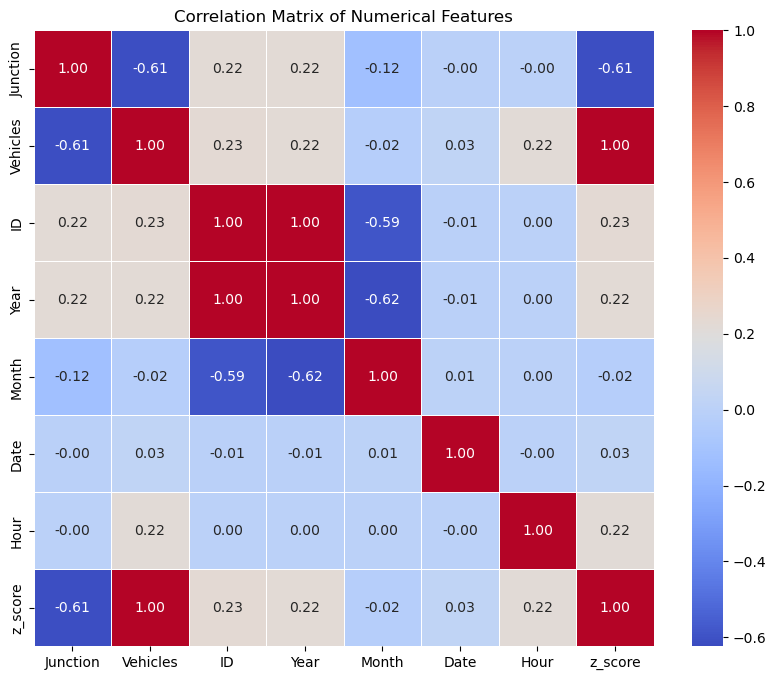

In [37]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Traffic Dataset - Exploratory Data Analysis Report
### Core Traffic Factors & Drivers

## Key Factors & Impact
* **Junction (Very High):** Extreme centralization; Junction 1 is the main bottleneck, while Junction 4 is the clearest.
* **Hour & Week_Type (Very High):** Weekday daytime and evening rush hours experience maximum congestion; weekends are significantly lighter.
* **Day (High):** Mid-week peak (Tuesday–Thursday) carries the heaviest operational load.
* **Month (Medium):** Mid-year rise, late-year dip. Driven by regional weather, holidays, and academic calendar breaks.
* **Year (Med-High):** Upward trend. Reflects compounding urban growth, population expansion, and vehicle ownership.
## Primary Drivers
1. **Time of Day:** Rush hour vs. off-peak cycles.
2. **Week Type:** Structural shift between weekday commuting and weekend leisure.\
3. **Location** (Junction-specific bottlenecks)
4. **Seasonality** (Monthly fluctuations)


### Key Findings
- Peak traffic occurs during weekday daytime and evening hours.
- Lowest traffic occurs during early morning hours.
- Junction 1 is the busiest and most overloaded junction.
- Weekdays have much higher traffic than weekends.
- Traffic volume shows a gradual increasing trend over time.
- Major congestion windows occur during midweek and business hours

### Systemic Conclusions

Traffic is highly predictable, commuter-driven, and governed by daily office, school, and business routines.
* **Temporal Peaks:** Traffic surges during weekdays and daytime/evening hours. It drops significantly on weekends and early mornings.
* **Spatial Hotspot:** **Junction 1** is the primary bottleneck and major traffic hotspot for the entire network.
* **Growth Trend:** Traffic volume shows a gradual, compounding increase over time due to rising urban mobility demands.

# Future Action Items

* **City Authorities & Planners:** Upgrade infrastructure and optimize signals at Junction 1. Schedule road maintenance during early mornings, Sundays, or seasonal dips.
* **Logistics & Fleet Operators:** Avoid Junction 1 during weekday peaks. Shift deliveries to early mornings, late nights, and weekends.
* **Navigation & Tech Systems:** Implement predictive rerouting during midweek rush hours, weighting Junction 1 heavily.
* **Traffic Enforcement:** Deploy maximum personnel around Junction 1 corridors during Tuesday–Thursday peak windows